### Cài đặt các thư viện

In [1]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Khai báo thư viện

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

### 2. Tải và đọc dữ liệu

In [4]:
X_train = pd.read_csv("D:\DS111\DoAnDS111\processed_data\X_train.csv")
y_train = pd.read_csv("D:\DS111\DoAnDS111\processed_data\y_train.csv")

data = X_train.copy()
data["y"] = y_train
data.head()

,job,marital,education,default,housing,loan,contact,day,month,poutcome,age_group,balance_log,balance_flag,duration_log,campaign_log,pdays_contacted,pdays_log,previous_log,y
0,4,1,3,0,1,0,0,0.985243,0.965926,3,4,0.507291,0,0.430097,-0.909638,0,-0.467735,-0.424985,0
1,9,2,2,0,1,0,0,0.985243,0.965926,3,3,-0.588304,0,-0.160655,-0.909638,0,-0.467735,-0.424985,0
2,2,1,2,0,1,1,0,0.985243,0.965926,3,2,-0.604089,0,-0.898547,-0.909638,0,-0.467735,-0.424985,0
3,1,1,2,0,1,0,0,0.985243,0.965926,3,3,0.203197,0,-0.693703,-0.909638,0,-0.467735,-0.424985,0
4,4,1,3,0,1,0,0,0.985243,0.965926,3,2,-0.471857,0,-0.249885,-0.909638,0,-0.467735,-0.424985,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45084 entries, 0 to 45083
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job              45084 non-null  int64  
 1   marital          45084 non-null  int64  
 2   education        45084 non-null  int64  
 3   default          45084 non-null  int64  
 4   housing          45084 non-null  int64  
 5   loan             45084 non-null  int64  
 6   contact          45084 non-null  int64  
 7   day              45084 non-null  float64
 8   month            45084 non-null  float64
 9   poutcome         45084 non-null  int64  
 10  age_group        45084 non-null  int64  
 11  balance_log      45084 non-null  float64
 12  balance_flag     45084 non-null  int64  
 13  duration_log     45084 non-null  float64
 14  campaign_log     45084 non-null  float64
 15  pdays_contacted  45084 non-null  int64  
 16  pdays_log        45084 non-null  float64
 17  previous_log

In [6]:
# Kiểm tra giá trị khuyết
data.isnull().sum()

job                0
marital            0
education          0
default            0
housing            0
loan               0
contact            0
day                0
month              0
poutcome           0
age_group          0
balance_log        0
balance_flag       0
duration_log       0
campaign_log       0
pdays_contacted    0
pdays_log          0
previous_log       0
y                  0
dtype: int64

In [7]:
data.columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'day', 'month', 'poutcome', 'age_group', 'balance_log', 'balance_flag',
       'duration_log', 'campaign_log', 'pdays_contacted', 'pdays_log',
       'previous_log', 'y'],
      dtype='object')

In [8]:
data.dtypes

job                  int64
marital              int64
education            int64
default              int64
housing              int64
loan                 int64
contact              int64
day                float64
month              float64
poutcome             int64
age_group            int64
balance_log        float64
balance_flag         int64
duration_log       float64
campaign_log       float64
pdays_contacted      int64
pdays_log          float64
previous_log       float64
y                    int64
dtype: object

In [9]:
data.shape

(45084, 19)

### 3. Thực hiện thống kê mô tả

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
job,45084.0,4.291656e+00,3.239756,0.000000,1.000000,4.000000,7.000000,10.000000
marital,45084.0,1.167798e+00,0.608548,0.000000,1.000000,1.000000,2.000000,2.000000
education,45084.0,2.149987e+00,0.658345,1.000000,2.000000,2.000000,3.000000,3.000000
default,45084.0,1.805519e-02,0.133153,0.000000,0.000000,0.000000,0.000000,1.000000
housing,45084.0,5.572265e-01,0.496720,0.000000,0.000000,1.000000,1.000000,1.000000
loan,45084.0,1.606778e-01,0.367238,0.000000,0.000000,0.000000,0.000000,1.000000
contact,45084.0,6.392512e-02,0.244622,0.000000,0.000000,0.000000,0.000000,1.000000
day,45084.0,9.899796e-01,0.006946,0.979582,0.983489,0.991298,0.996807,1.000000
month,45084.0,9.491528e-01,0.036603,0.866025,0.898941,0.965926,0.965926,1.000000
poutcome,45084.0,2.559223e+00,0.989787,0.000000,3.000000,3.000000,3.000000,3.000000


### 4. Kiểm tra các thuộc tính sau tiền xử lý

Vì sau tiền xử lý thì có thêm các thuộc tính mới nên chúng tôi tiến hành tạo phân phối numerical mới sau phần log_transform và scaling data để kiểm tra xem log-transform và Standard Scaler đã làm các phân phối trở nên cân bằng hơn hay chưa.

In [11]:
df = data.copy()

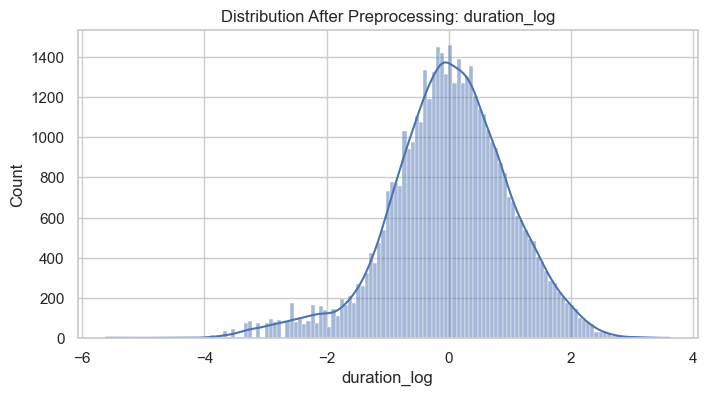

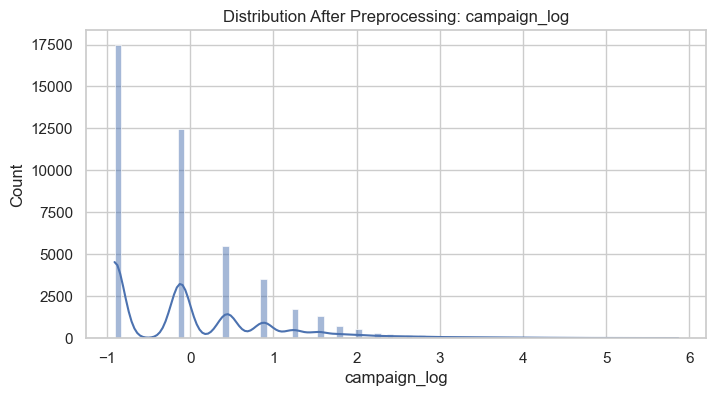

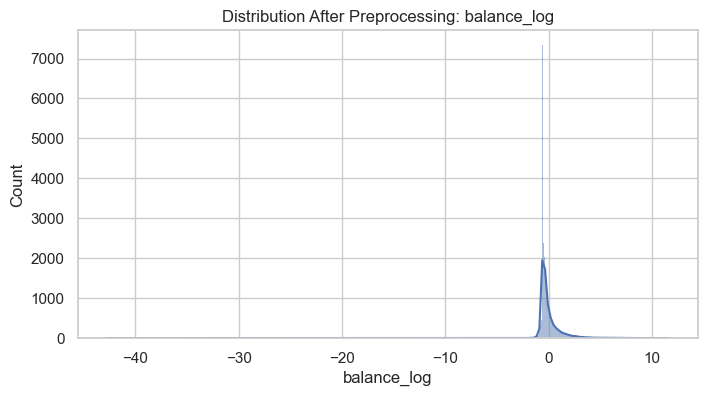

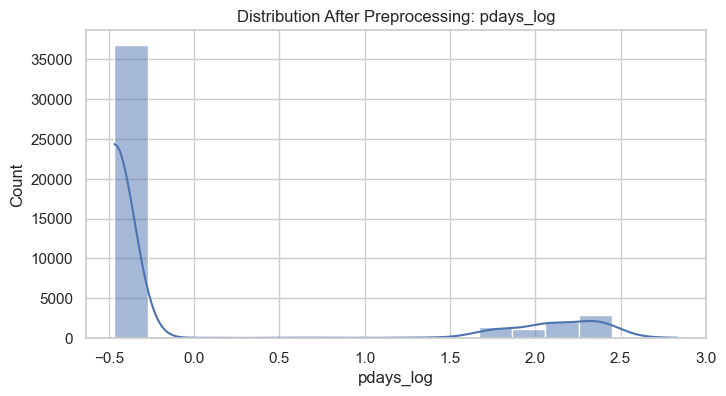

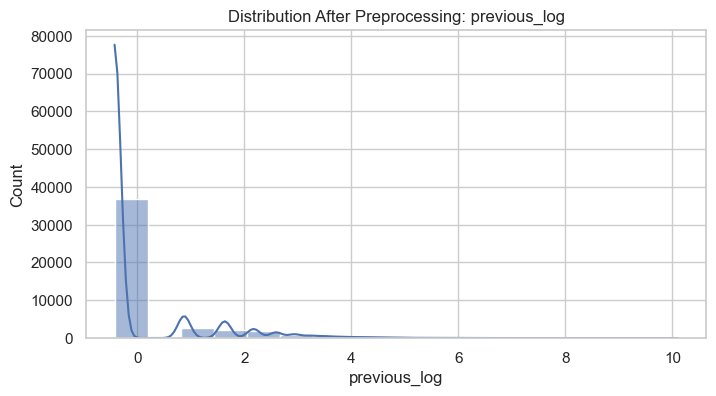

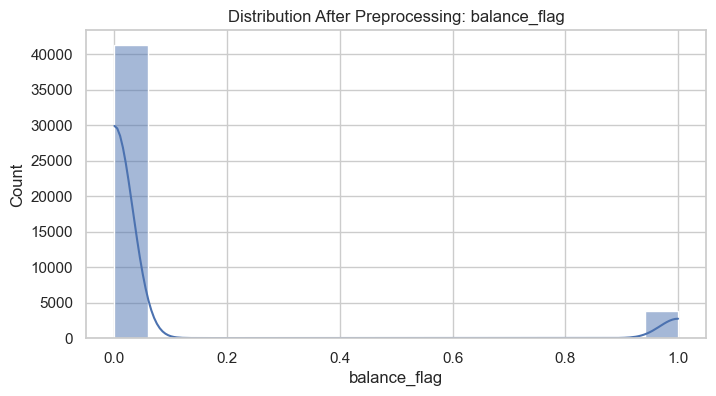

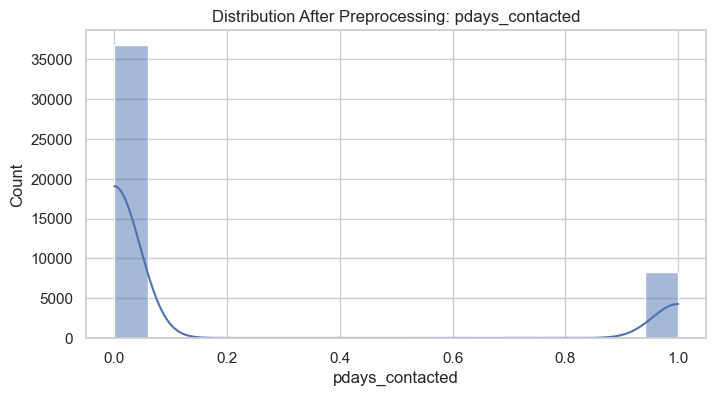

In [12]:
numerical_features = [
    'duration_log',
    'campaign_log',
    'balance_log',
    'pdays_log',
    'previous_log',
    'balance_flag',
    'pdays_contacted'
]

for col in numerical_features:
    plt.figure(figsize=(8,4))
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution After Preprocessing: {col}")
    plt.show()



#### 5. Kiểm tra mối quan hệ giữa các Feature với Target

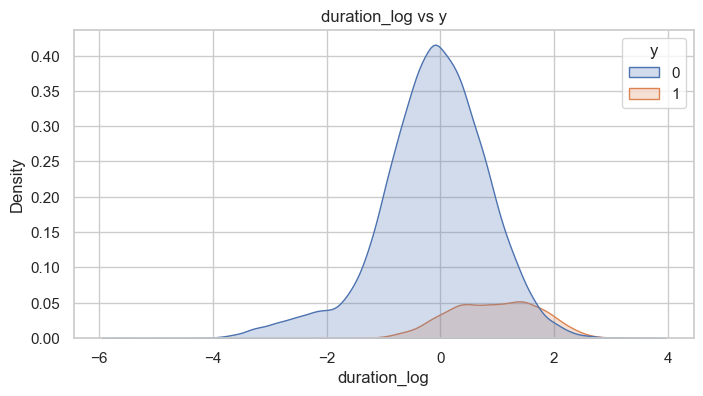

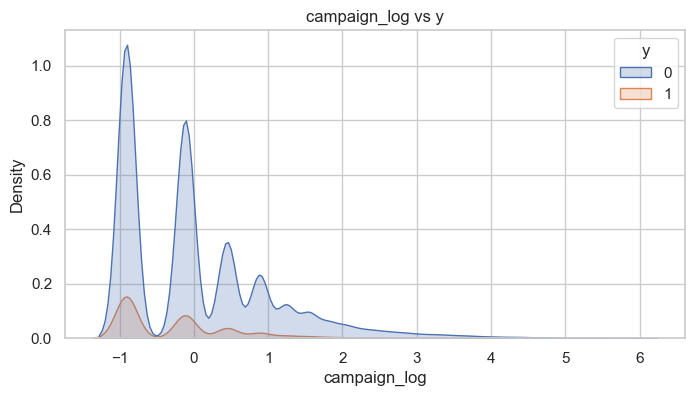

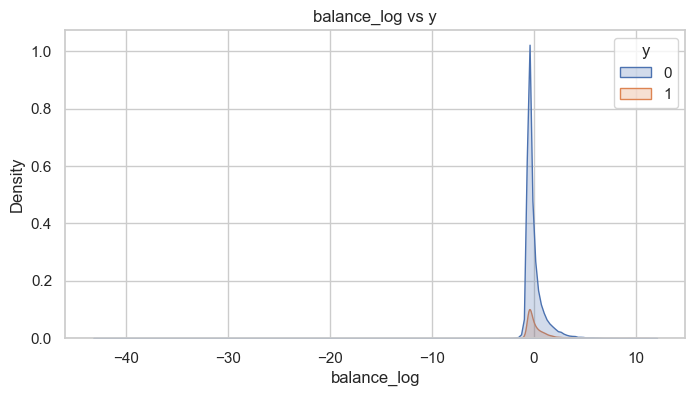

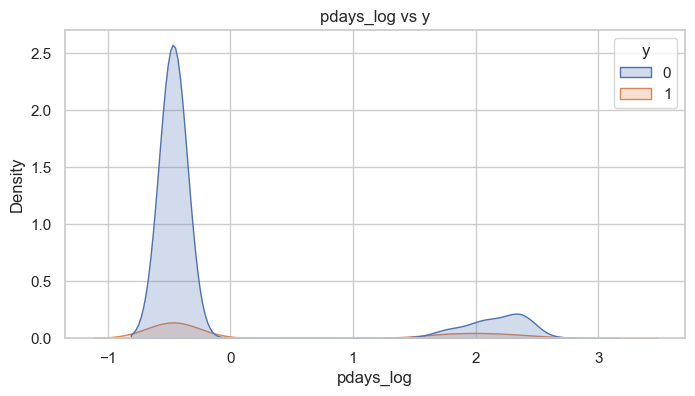

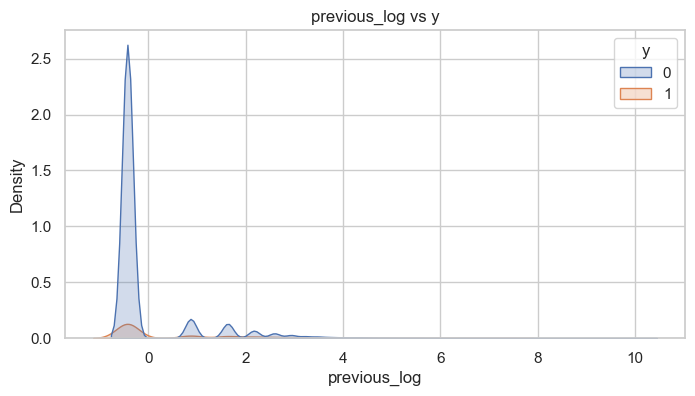

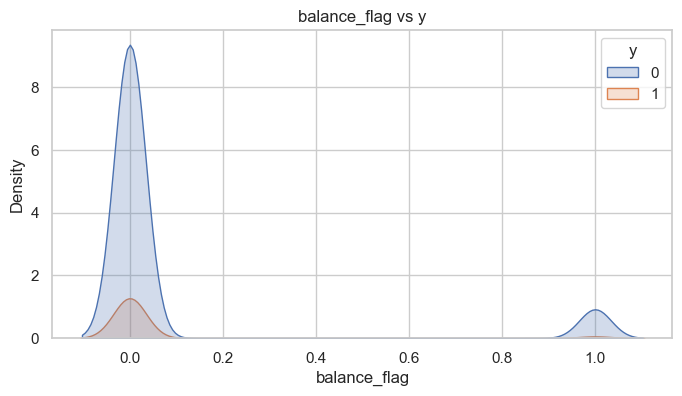

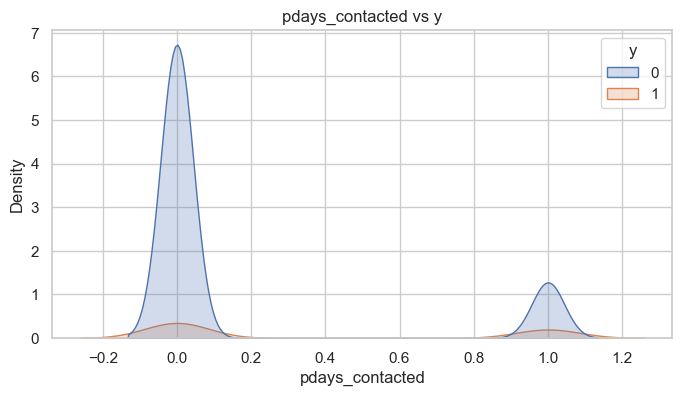

In [13]:
numerical_features = [
    'duration_log',
    'campaign_log',
    'balance_log',
    'pdays_log',
    'previous_log',
    'balance_flag',
    'pdays_contacted'
]

for col in numerical_features:
    plt.figure(figsize=(8,4))
    sns.kdeplot(data=data, x=col, hue='y', fill=True)
    plt.title(f"{col} vs y")
    plt.show()

### 6. Correlation Heatmap After Preprocessing

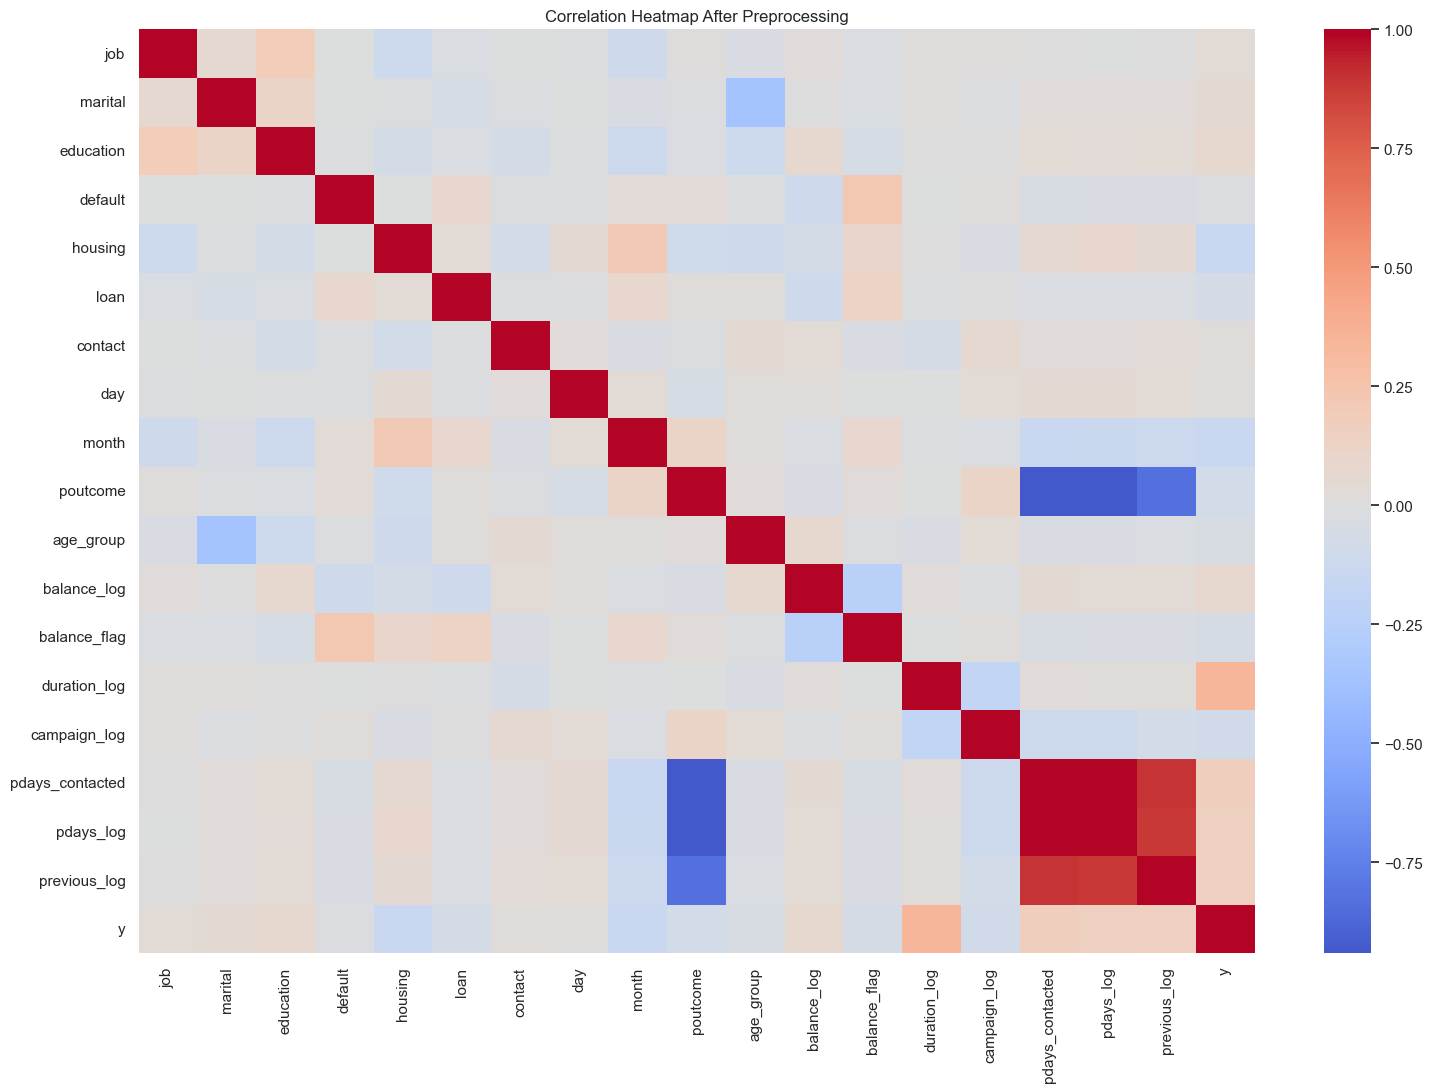

In [14]:
plt.figure(figsize=(18,12))
corr = data.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap After Preprocessing")
plt.show()

Tương quan có sự thay đổi so với trước khi tiền xử lý, với các biến liên quan đến pdays thì có tương quan dương mạnh, trong khi biến poutcome và pdays thì 2 biến này tương quan âm lại rất thấp. Trong đó các biến job, marital, education cũng có sự ảnh hưởng tới kết quả khá cao khi chỉ số tương quan dương từ khoảng 0.25-0.5

### 7. Tạo Bins (phân nhóm) cho phân tích tương tác

In [15]:
data["duration_bin"] = pd.qcut(
    data["duration_log"], q=4,
    labels=["D_Low","D_Med","D_High","D_VHigh"],
    duplicates='drop'
)

data["balance_bin"] = pd.qcut(
    data["balance_log"], q=4,
    labels=["B_Low","B_Med","B_High","B_VHigh"],
    duplicates='drop'
)

data["campaign_bin"] = pd.cut(
    data["campaign_log"], bins=4,
    labels=["C_Low","C_Med","C_High","C_VHigh"],
    duplicates='drop'
)

data["pdays_bin"] = pd.cut(
    data["pdays_log"], bins=4,
    labels=["P_Low","P_Med","P_High","P_VHigh"],
    duplicates='drop'
)


### 8. Heatmap: Duration vs Age Group

C:\Users\Admin\AppData\Local\Temp\ipykernel_12680\3728228387.py:25: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(
C:\Users\Admin\AppData\Local\Temp\ipykernel_12680\3728228387.py:25: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(
C:\Users\Admin\AppData\Local\Temp\ipykernel_12680\3728228387.py:25: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(
C:\Users\Admin\AppData\Local\Temp\ipykernel_12680\3728228387.py:25: FutureWarning: The d

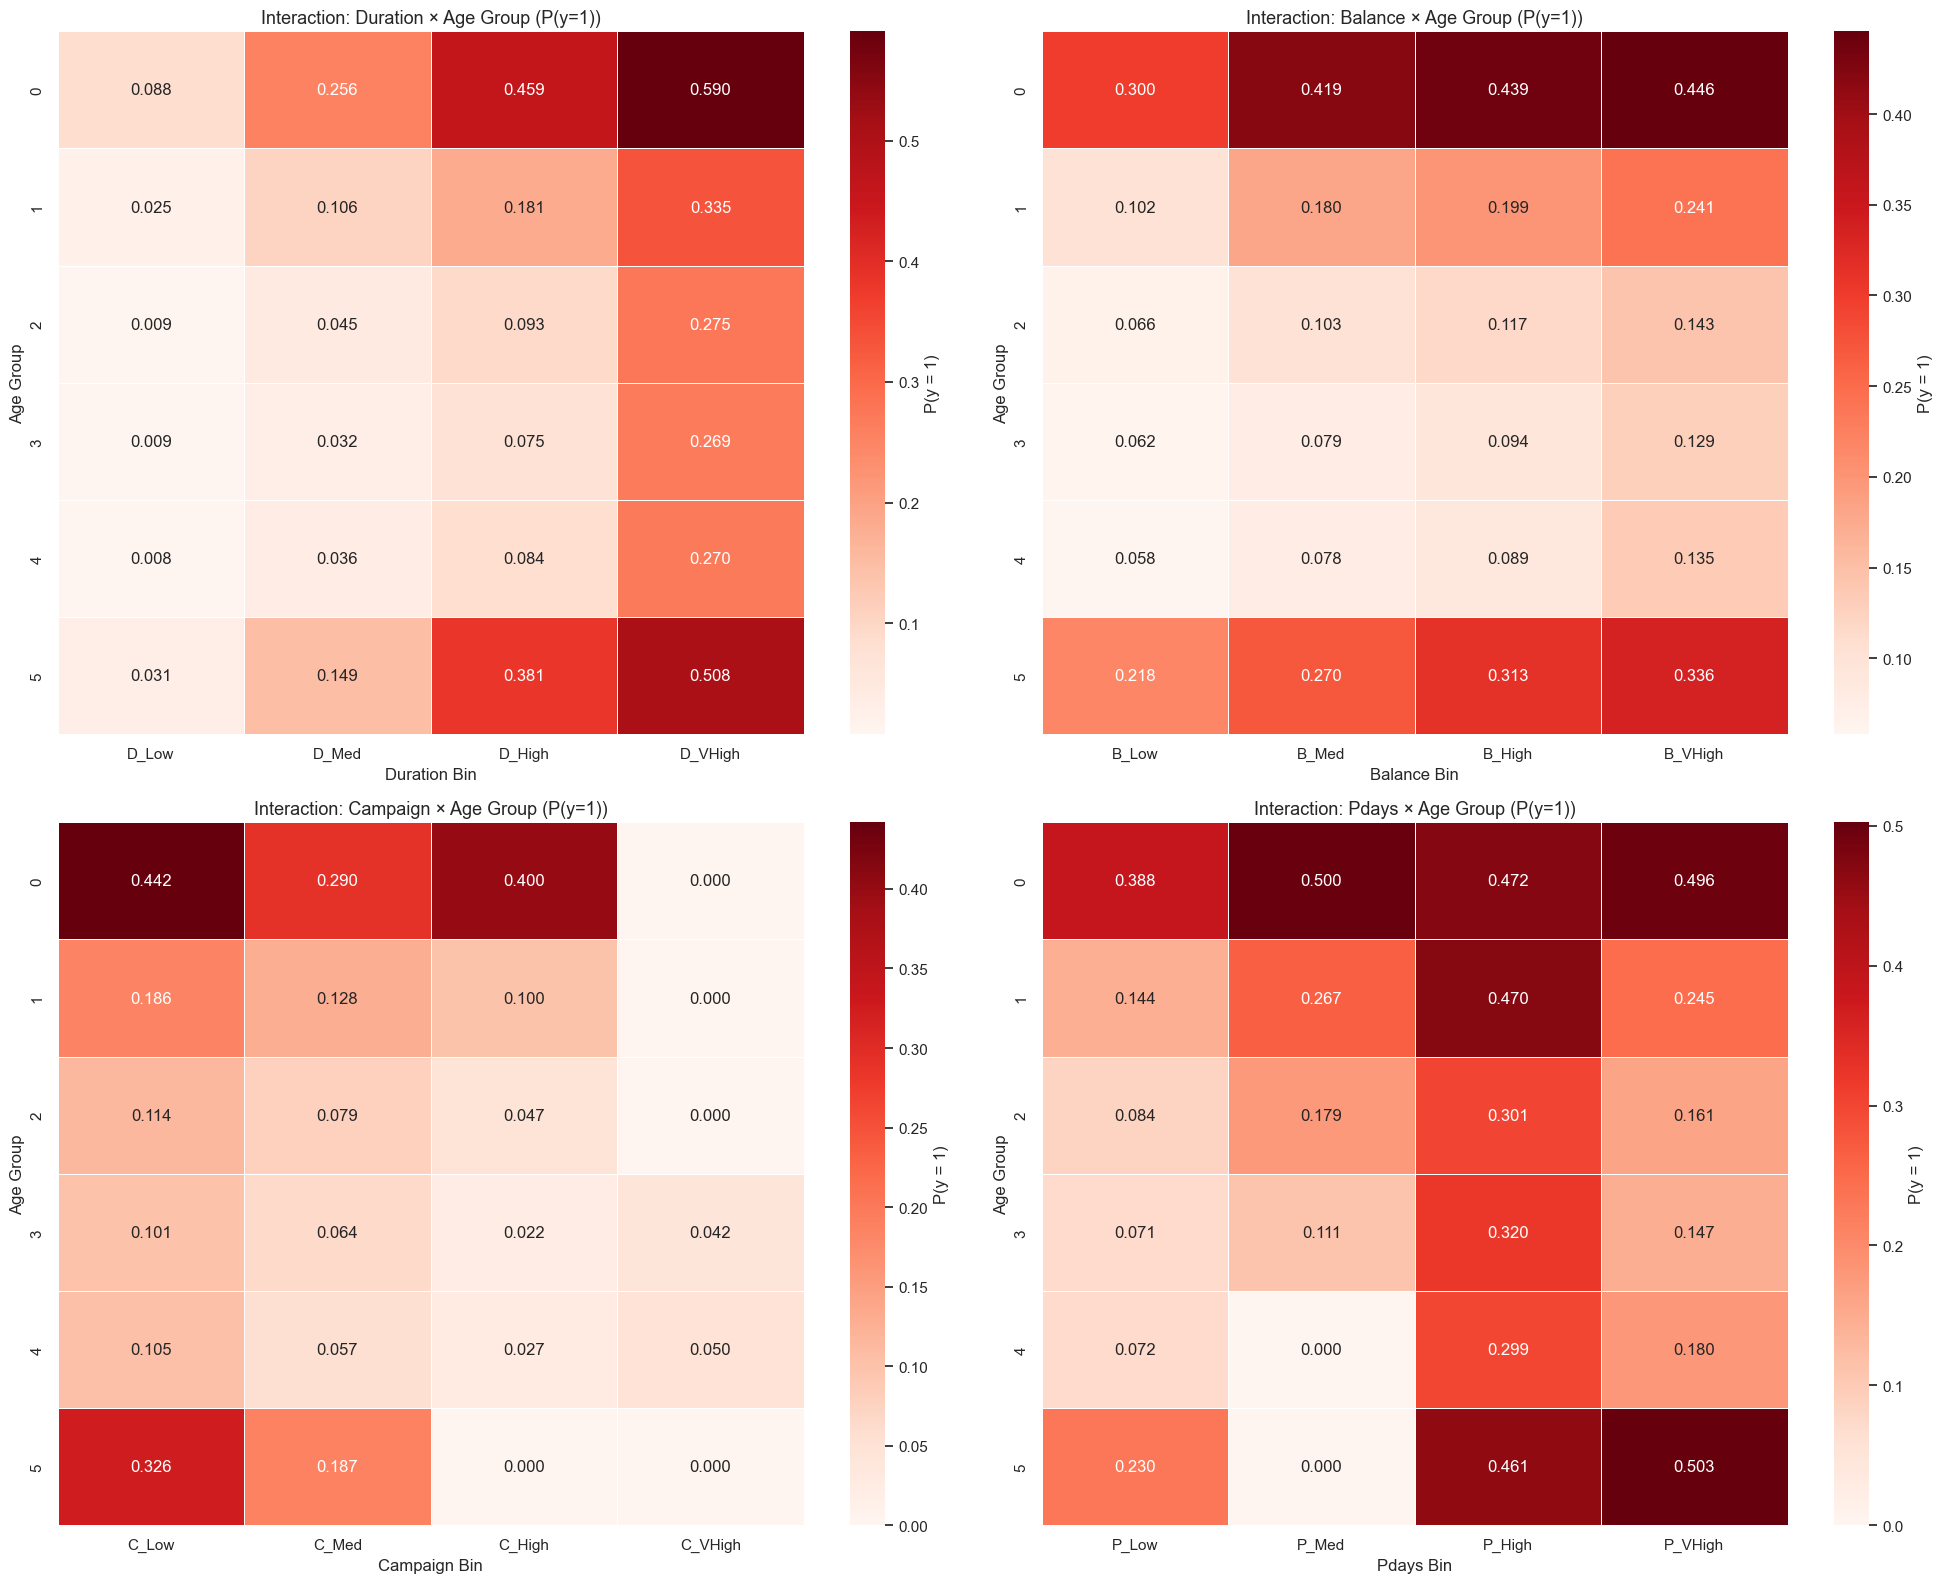

In [16]:
# Đảm bảo age_group có thứ tự đúng
data["age_group"] = pd.Categorical(
    data["age_group"],
    categories=sorted(data["age_group"].unique()),
    ordered=True
)

# Tạo danh sách các cột bin cần phân tích
interaction_bins = [
    ("duration_bin", "Duration"),
    ("balance_bin", "Balance"),
    ("campaign_bin", "Campaign"),
    ("pdays_bin", "Pdays")
]


plt.figure(figsize=(20, 16))
plot_index = 1

for bin_col, title_prefix in interaction_bins:
    if bin_col not in data.columns:
        continue
    
    # Pivot table tính P(y=1) cho interaction
    pivot = data.pivot_table(
        index="age_group",
        columns=bin_col,
        values="y",
        aggfunc="mean"
    ).fillna(0)
    
    # subplot
    plt.subplot(2, 2, plot_index)
    sns.heatmap(
        pivot,
        annot=True,
        cmap="Reds",
        fmt=".3f",
        linewidths=.5,
        cbar_kws={'label': 'P(y = 1)'}
    )
    
    plt.title(f"Interaction: {title_prefix} × Age Group (P(y=1))", fontsize=13)
    plt.xlabel(f"{title_prefix} Bin")
    plt.ylabel("Age Group")
    
    plot_index += 1

plt.tight_layout()
plt.show()


NOTE: CÁC NHÓM TUỐI: {0: U30, 1: U40, 2: U50, 3: U60, 4: U70, 5: U100}
1. Duration càng cao → tỉ lệ “yes” tăng mạnh trên mọi nhóm tuổi. Trong đó
- Nhóm tuổi U100 (nhóm lớn tuổi nhất) có tỉ lệ đăng ký cao khi thời gian trò chuyện/trao đổi dài.
- Các nhóm U30, U40, U50… có xu hướng tăng nhưng vẫn thấp hơn U100 & U70.
=> Từ đó có thể xác định Duration là yếu tố quyết định quan trọng nhất và người được tư vấn lâu hơn thường dễ đồng ý hơn.
- Khi thời lượng cuộc gọi tăng, tỷ lệ “YES – đăng ký gửi tiết kiệm” tăng mạnh ở tất cả các phân khúc.

2. Biểu đồ cho thấy người có Balance cao (Số dư tài khoản cao) thì xu hướng đăng ký (yes) lại không nhiều lắm
- Nhóm tuổi U100 và U30 lại có tỷ lệ đăng ký cao nếu balance cao. Trong khi 4 nhóm tuổi còn lại thì gần như không bị ảnh hưởng gì nếu số dư cao hay thấp.
=> Balance sẽ là thuộc tính có ảnh hưởng nhẹ đến khả năng đăng ký của khách hàng

3. Campaign (số lần liên hệ trong 1 chiến dịch): có thể thấy được nếu số campaign quá cao, có nghĩa là gọi quá nhiều thì tỷ lệ khách hàng đăng ký lại rất thấp (có thể họ thấy bị làm phiền, spam, ...), có thể thấy P(y=1) giảm mạnh, và đáng chú ý là C_VHigh toàn cột = 0 hoặc gần 0 -> người bị liên hệ tư vấn quá nhiều thường sẽ không đăng ký
- Tuy nhiên, ở nhóm U30 thì vẫn có khả năng đăng ký nếu gọi khá nhiều, các nhóm U40 - U70 thì hầu như không đăng ký nếu số lần liên hệ nhiều, và nhóm tuổi U100 vẫn có xu hướng đăng ký tuy nhiên vẫn sẽ không đăng ký nếu bị làm phiền nhiều.

4. Pdays (số lần liên hệ từ lần trước): có thể thấy khi pdays thấp thì tỷ lệ khách hàng đăng ký chiến dịch lại tăng, nhưng khi pdays cao thì tỷ lệ đăng ký lại vẫn cao => hiệu ứng phi tuyến mạnh (Quan hệ phi tuyến nghĩa là biến Pdays và xác suất khách hàng đồng ý không thay đổi theo một tỷ lệ cố định. Tỷ lệ đồng ý cao ở mức Pdays thấp, thấp ở mức trung bình, và lại tăng ở mức rất cao.)
- Nhóm tuổi U30 và U100 có tỷ lệ đăng ký cao kể cả pdays cao hay thấp
- Các nhóm tuổi còn lại có xu hướng đăng ký nếu pdays ở mức cao (P_High)

=> Duration là yếu tố mạnh nhất => Thời lượng cuộc gọi càng dài => tỷ lệ đồng ý càng cao
=> Campaign có ảnh hưởng tiêu cực => Gọi nhiều => khách hàng chán và giảm khả năng đồng ý
=> Balance ít ảnh hưởng => chỉ nhóm 0 và 5 phản ứng tốt khi balance cao.
=> Pdays quan hệ phi tuyến => cả last-contact gần và rất xa đều tăng tỷ lệ đồng ý.
=> Nhóm tuổi U30 và U100 phản ứng tích cực hơn ở tất cả các biến => Đây là phân khúc khách hàng dễ tiếp cận nhất.

C:\Users\Admin\AppData\Local\Temp\ipykernel_12680\2599795931.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(


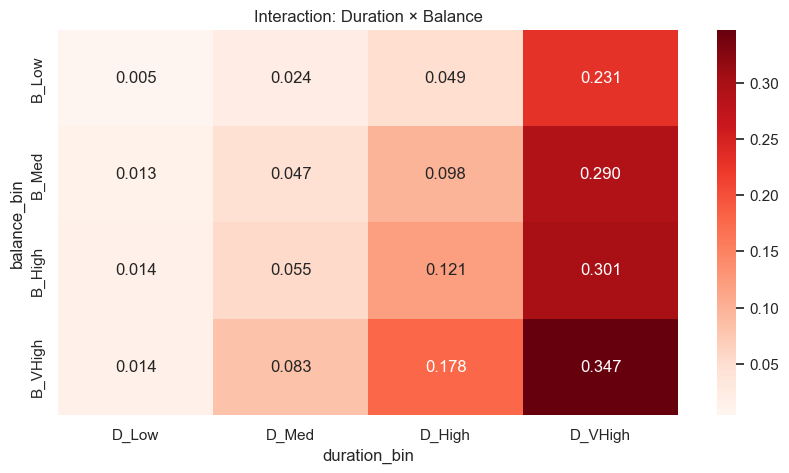

In [17]:
pivot = data.pivot_table(
    index="balance_bin",
    columns="duration_bin",
    values="y",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="Reds", fmt=".3f")
plt.title("Interaction: Duration × Balance")
plt.show()


Duration (thời lượng cuộc gọi) dài → tỉ lệ “yes” tăng mạnh trên mọi mức Balance. Nhóm có Balance rất cao (B_VHigh) tăng tỉ lệ mạnh nhất.
=>  Khách có số dư tài khoản cao thường dễ chấp nhận đầu tư hơn → ảnh hưởng của duration với balance mạnh hơn.
=> Balance là biến độc lập mạnh, nhưng tăng mạnh khi kết hợp với Duration → đây là 1 sự tương tác quan trọng cần lưu ý.

C:\Users\Admin\AppData\Local\Temp\ipykernel_12680\2770154254.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_sub.pivot_table(
C:\Users\Admin\AppData\Local\Temp\ipykernel_12680\2770154254.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_sub.pivot_table(
C:\Users\Admin\AppData\Local\Temp\ipykernel_12680\2770154254.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_sub.pivot_table(
C:\Users\Admin\AppData\Local\Temp\ipykernel_12680\2770154254.py:9: FutureWarning: The

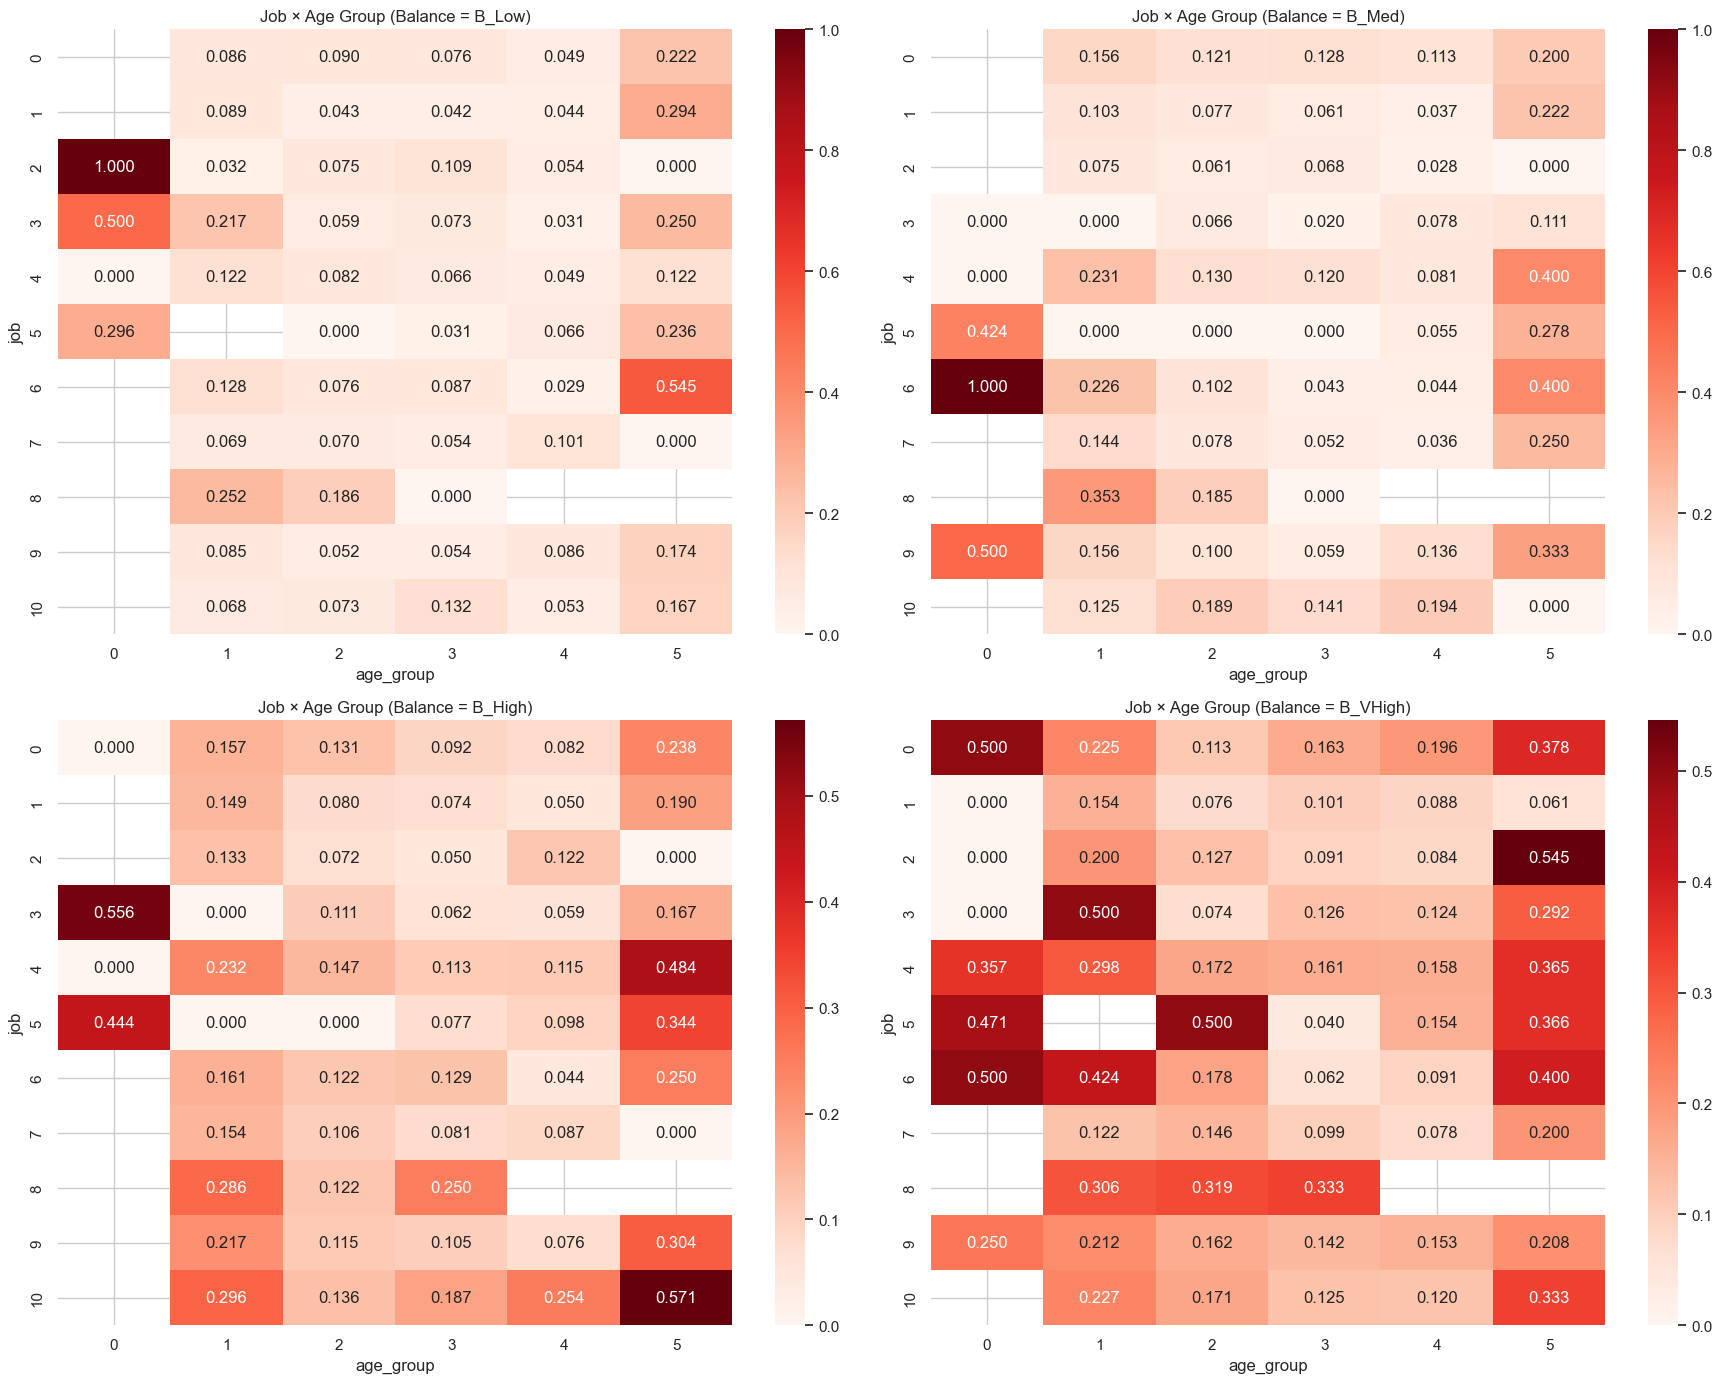

In [18]:
balance_levels = ["B_Low","B_Med","B_High","B_VHigh"]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, bl in enumerate(balance_levels):
    df_sub = data[data["balance_bin"] == bl]
    
    pivot = df_sub.pivot_table(
        index="job",
        columns="age_group",
        values="y",
        aggfunc="mean"
    )
    
    sns.heatmap(pivot, annot=True, cmap="Reds", fmt=".3f",
                ax=axes[i])
    axes[i].set_title(f"Job × Age Group (Balance = {bl})")

plt.tight_layout()
plt.show()


Nhận xét: 
- Nhóm U100, U70 thường có tỷ lệ cao hơn trên nhiều job.
- Certain jobs consistently cao hơn: entrepreneur (B_Low), retired, management, self-employed, unemployed. Riêng nhóm student cũng cao nhưng thay đổi theo balance.
- Balance càng cao → interaction càng mạnh
    - Khi balance thấp → heatmap “nhạt” hơn
    - Khi balance cao → màu đậm rõ rệt ở job retired, self-employed, management, unemployed
- Đối với các trường hợp:
    - Balance = B_Low: Chỉ một vài job có tỉ lệ cao bất thường (entrepreneur, housemaid nhưng đây có thể do sample ít → caution!)
    - Balance = B_Med: management, retired nổi bật
    - Balance = B_High: unemployed, management, services, student phản hồi mạnh hơn các nhóm khác
    - Balance = B_VHigh: retired, management, entrepreneur, self-employed → đậm rõ rệt → Người vừa có tiền, vừa ở nhóm ít áp lực tài chính / tự do thời gian → dễ đầu tư hơn.